## Projected constraints

For a cleaner description see the Boundary Sensitivity paper.

### Surface integral
For the functional defined as a surface integral
$$ G(\Omega) = \int_{\delta\Omega} g(x) \mathrm{d}s(x) $$
the shape derivative w.r.t. a vector field $\delta{x}$ is
$$ G'(\Omega)(\delta{x}) = \int_{\delta\Omega} \left( \frac{\partial{g}}{\partial{n}} + \kappa{g} \right) \delta{x}\cdot n \ \mathrm{d}s $$

### Volume integral

Similarly, for the functional defined as a volume integral of $f$
$$ F(\Omega) = \int_{\Omega} f(x) \mathrm{d}x $$
the shape derivative w.r.t. a vector field $\delta{x}$ is
$$ F'(\Omega)(\delta{x}) 
= \int_{\Omega} \mathrm{div}(f\delta{x}) \ \mathrm{d}x 
= \int_{\Omega} f\delta{x}\cdot n \ \mathrm{d}x $$

Inserting the shape gradients we get
$$ F'(\Omega)(\delta{x}) = \delta\Theta \cdot \int_{\Omega} \frac{-f \nabla_\Theta f}{||\nabla_x f||} \mathrm{d}x := \delta\Theta \cdot B_f $$

Consider keeping this functional constant under the perturbation. For this, we are allowed to pick any parameter update $\delta \Theta$ s.t. $\delta \Theta ^ \top B_f (x) = 0$, i.e., $\delta \Theta$ must be orthogonal to $\delta B_f$. This gives $n-1$ degrees of freedom for a general $B_f$, so we can still minimize some other functional. In this notebook, we minimize the mean-curvature while keeping a constant volume.

In [7]:
import torch
from tqdm.notebook import trange
import copy
import k3d
import matplotlib.pyplot as plt

from gradients import get_grads, get_hessian
from utils import get_mean_curvature, norm, grads_to_basis, solve_lstsq, update_params

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import GeneralNet
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton
from util.visualization.utils_mesh import get_mesh

device = 'cuda'
torch.set_default_device(device)

In [8]:
"""Load the model"""
model = GeneralNet(ks=[3,32,32,32,1], act=torch.sin)
model.load_state_dict(torch.load('3,32,32,32,1,sin,bunny', map_location=device))

"""Plot the initial model"""
verts, faces = get_mesh(
    model.float(),
    N=128, 
    device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=1
)
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig.display()
model.double()

Output()

GeneralNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [57]:
# Gauss-Newton weights:
from training.optimizers import GaussNewton, GaussNewtonWoodburyBig

loss_weights = {"mean_curvature": 1.0}

# pts = sample_model_surface_binsearch(model.double(), torch.zeros([0,3]))

config = {
    "pts_surface": pts,
    "loss_weights": loss_weights,
    "regularization": 1e-5,
}

optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)

In [3]:
def compute_J_batchwise(model, pts, batch_size=512):
    """
    Computes JTJ = (JᵀJ)/N in batches over points for memory efficiency.

    Args:
        model: model with grad_theta_r_mean_curvature
        pts (Tensor): (N, 3) input points
        batch_size (int): how many points per batch

    Returns:
        JTJ (Tensor): (D, D)
        JTr (Tensor): (D,)
        r_all (Tensor): (N,)
    """
    N = len(pts)

    JTJ = None
    JTr = None
    r_all = []

    for i in range(0, N, batch_size):
        pts_batch = pts[i:i+batch_size]

        r_batch = model.r_mean_curvature(model.params, pts_batch).squeeze(1)

        # Compute J = dr/dθ
        dr_dict = model.grad_theta_r_mean_curvature(model.params, pts_batch)
        J_batch = torch.cat([v.flatten(start_dim=1) for v in dr_dict.values()], dim=1)  # (B, D)

        # Accumulate JTJ and JTr
        if JTJ is None:
            D = J_batch.shape[1]
            JTJ = torch.zeros(D, D, dtype=torch.float64)
            JTr = torch.zeros(D, dtype=torch.float64)

        JTJ += torch.einsum('bi,bj->ij', J_batch, J_batch)
        JTr += torch.einsum('bi,b->i', J_batch, r_batch)
        r_all.append(r_batch)

    JTJ /= N
    JTr /= N
    r = torch.cat(r_all, dim=0)

    return JTJ, JTr, r

def compute_basis_dV_batchwise(model, pts, batch_size=512):
    """
    Computes the mean derivative of volume w.r.t. parameters in batches for memory efficiency.

    Args:
        model: model with `get_grads` method returning dfdx and dfdO
        pts (Tensor): (N, 3) input points
        batch_size (int): how many points per batch

    Returns:
        basis_dV (Tensor): (D,)
    """
    N = len(pts)
    basis_dV = None

    for i in range(0, N, batch_size):
        pts_batch = pts[i:i+batch_size]

        dfdx_batch, dfdO_batch = get_grads(model, pts_batch)  # (B, 3), (B, D)
        norm_dfdx_batch = torch.linalg.norm(dfdx_batch, dim=1, keepdim=True)  # (B, 1)
        contrib = -dfdO_batch / norm_dfdx_batch  # (B, D)

        if basis_dV is None:
            D = contrib.shape[1]
            basis_dV = torch.zeros(D, dtype=torch.float64)

        basis_dV += contrib.sum(0)

    basis_dV /= N
    return basis_dV



In [9]:
pts_space = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts = sample_model_surface_newton(model, pts_space) 

  0%|          | 0/500 [00:00<?, ?it/s]

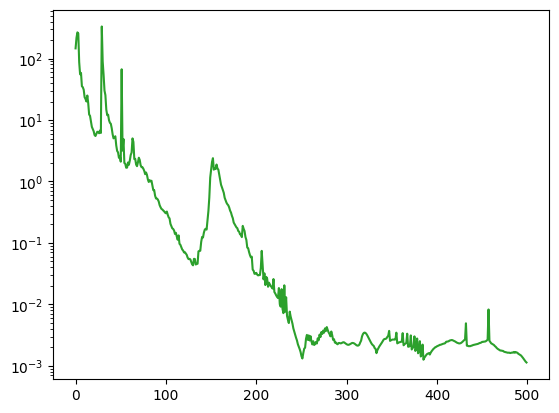

In [10]:
""""""
from torch.nn.utils import parameters_to_vector, vector_to_parameters
model.double()
lr = 1e-1
hard_constraint = True
N_iter = 500

## debugging
losses_over_iters = torch.zeros([N_iter,3])
params_over_iters = []

pbar = trange(N_iter)
for i in pbar:

    # pts = sample_model_surface_binsearch(model.double(), torch.zeros([0,3]))
    pts = sample_model_surface_newton(model, pts_space)
    # config["pts_surface"] = pts
    # optimizer.config = config
    
    if len(pts)==0: break
    
    dfdx, dfdO = get_grads(model, pts) ## NOTE: probably you can reuse some existing function. dfdx and dfdO are the derivatives of f wrt x and params, respectively, times the batch of points
    # Hfx = get_hessian(model, pts)
    k = model.r_mean_curvature(model.params, pts).squeeze(1) ## TODO: can use your function here, but this also works
    loss_curvature = k.square().sum() / len(pts)

    ## Compute the vector of volume change for each parameter.
    ## In proper Monte-Carlo integration, we would need to normalize by samples and area.
    basis_dV = (-dfdO/norm(dfdx)[:,None]).sum(0) / len(pts)
    # basis_dV = compute_basis_dV_batchwise(model, pts, batch_size=1000)

    if hard_constraint:
        ## Hard constraint via subspace projection:
        ## First, solve the LSTSQ. NOTE: you will get dO from GN. Doing LSTSQ is specific to the boundary sensitivity paper.
        # B = grads_to_basis(dfdx, dfdO)
        # c = -k
        # dO = solve_lstsq(B, c, lmbd=0.1, method='lstsq', verbose=False)
        # dO = optimizer.calculate_update()

        dr_dict = model.grad_theta_r_mean_curvature(model.params, pts)  # each value: (B, param_dim)
        J = torch.cat([p.flatten(start_dim=1) for p in dr_dict.values()], dim=1)  # shape: (B, D)
        
        r = k  # residual = mean curvature
        JTJ = torch.einsum('bi,bj->ij', J, J) / len(pts)
        JTr = torch.einsum('bi,b->i', J, r) / len(pts)

        # JTJ, JTr, r = compute_J_batchwise(model, pts, batch_size=1000)
    
        # Solve the linear system
        eps = min(1e-1, loss_curvature)  # regularisation
        JTJ = JTJ + eps * torch.eye(JTJ.shape[0], dtype=torch.float64)
        x, _, _, _  = torch.linalg.lstsq(JTJ, JTr, driver="gels")
        dO = -x
        ## Second, project the initial update onto the isochrone subspace to get the projected update
        """
        NOTE: this is the most important line. 
        You really only need to calculate the basis_dV like above and apply this projection step on any parameter update of interest.
        """
        dO = dO - basis_dV*torch.dot(basis_dV, dO)/torch.dot(basis_dV, basis_dV)
    else:
        ## Soft-constraint via composite-LSTSQ, where the volume violation is weighted.
        ## This should not be used, but keeping it in for reference only.
        B = torch.vstack([
            grads_to_basis(dfdx, dfdO),
            1e3*basis_dV[None,:] ## dont weight this with more than 1e3
            ])
        c = torch.hstack([
            -k,
            torch.zeros(1)
            ])
        dO = solve_lstsq(B, c, lmbd=0.1, method='normalsolve', verbose=False)

    ## Debug only: calculate the volume change
    dV = torch.dot(basis_dV, dO)

    #####################
    ## --- Begin line search ---
    # theta_orig = parameters_to_vector(list(model.parameters()))
    # best_loss = float('inf')
    # best_theta = theta_orig
    # best_lr = lr

    # lrs = torch.logspace(0, -3, steps=10, dtype=dO.dtype, device=dO.device)

    # for lr_try in lrs:
    #     theta_try = theta_orig - lr_try * dO
    #     vector_to_parameters(theta_try, list(model.parameters()))

    #     # Re-evaluate surface and curvature
    #     dfdx_try, _ = get_grads(model, pts)
    #     Hfx_try = get_hessian(model, pts)
    #     k_try = get_mean_curvature(dfdx_try, Hfx_try)
    #     loss_try = k_try.square().sum().item() / len(pts)

    #     if loss_try < best_loss:
    #         best_loss = loss_try
    #         best_theta = theta_try
    #         best_lr = lr_try

    # vector_to_parameters(best_theta, list(model.parameters()))
    # lr = best_lr

    #####################

    ## Do the update
    update_params(model, lr*dO)
    
    ## Log
    pbar.set_description(f"loss_curvature: {loss_curvature.item():.2e} "
                         f"{len(pts)} "
                         f"{dV:.2e}"
                    )
    # losses_over_iters[i,0] = loss_val
    # losses_over_iters[i,1] = loss_normals
    losses_over_iters[i,2] = loss_curvature
    params_over_iters.append(copy.deepcopy(model.state_dict()))

fig, ax = plt.subplots()
ax.plot(losses_over_iters.cpu().detach())
ax.semilogy()
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

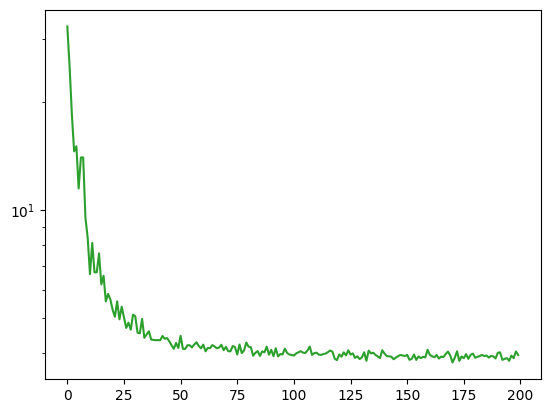

In [25]:
""""""
lr = 1e-3
hard_constraint = True
N_iter = 200

## debugging
losses_over_iters = torch.zeros([N_iter,3])
params_over_iters = []

pbar = trange(N_iter)
for i in pbar:

    pts = sample_model_surface_binsearch(model.double(), torch.zeros([0,3]))
    if len(pts)==0: break
    
    dfdx, dfdO = get_grads(model, pts) ## NOTE: probably you can reuse some existing function. dfdx and dfdO are the derivatives of f wrt x and params, respectively, times the batch of points
    # Hfx = get_hessian(model, pts)
    # k = get_mean_curvature(dfdx, Hfx) ## TODO: can use your function here, but this also works
    k = model.r_mean_curvature(model.params, pts).squeeze(1)
    loss_curvature = k.square().sum() / len(pts)

    ## Compute the vector of volume change for each parameter.
    ## In proper Monte-Carlo integration, we would need to normalize by samples and area.
    basis_dV = (-dfdO/norm(dfdx)[:,None]).sum(0) / len(pts)

    if hard_constraint:
        ## Hard constraint via subspace projection:
        ## First, solve the LSTSQ. NOTE: you will get dO from GN. Doing LSTSQ is specific to the boundary sensitivity paper.
        B = grads_to_basis(dfdx, dfdO)
        c = -k
        dO = solve_lstsq(B, c, lmbd=0.1, method='normalsolve', verbose=False)
        ## Second, project the initial update onto the isochrone subspace to get the projected update
        """
        NOTE: this is the most important line. 
        You really only need to calculate the basis_dV like above and apply this projection step on any parameter update of interest.
        """
        dO = dO - basis_dV*torch.dot(basis_dV, dO)/torch.dot(basis_dV, basis_dV)
    else:
        ## Soft-constraint via composite-LSTSQ, where the volume violation is weighted.
        ## This should not be used, but keeping it in for reference only.
        B = torch.vstack([
            grads_to_basis(dfdx, dfdO),
            1e3*basis_dV[None,:] ## dont weight this with more than 1e3
            ])
        c = torch.hstack([
            -k,
            torch.zeros(1)
            ])
        dO = solve_lstsq(B, c, lmbd=0.1, method='normalsolve', verbose=False)

    ## Debug only: calculate the volume change
    dV = torch.dot(basis_dV, dO)

    ## Do the update
    update_params(model, lr*dO)
    
    ## Log
    pbar.set_description(f"loss_curvature: {loss_curvature.item():.2e} "
                         f"{len(pts)} "
                         f"{dV:.2e}"
                    )
    # losses_over_iters[i,0] = loss_val
    # losses_over_iters[i,1] = loss_normals
    losses_over_iters[i,2] = loss_curvature
    params_over_iters.append(copy.deepcopy(model.state_dict()))

fig, ax = plt.subplots()
ax.plot(losses_over_iters.cpu().detach())
ax.semilogy()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

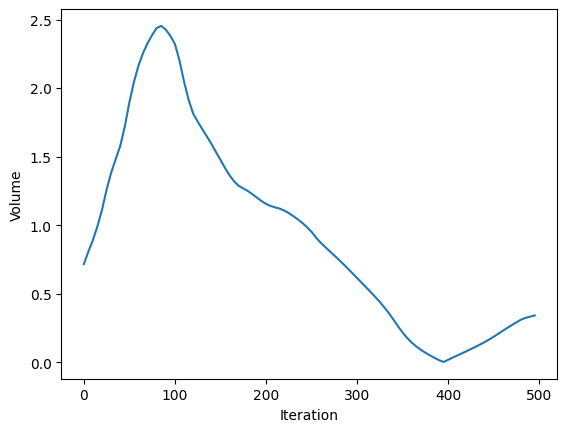

In [8]:
"""Visualization only, no function."""
"""Compute the volumes of the shapes over iterations"""
import trimesh

def get_volume(i):
    model.load_state_dict(params_over_iters[i])
    verts, faces = get_mesh(
        model.float(),
        N=128, 
        device=device,
        bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
        bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
        chunks=1
    )
    mesh = trimesh.Trimesh(vertices=verts, faces=faces[:,::-1])
    return abs(mesh.volume)

volumes = {i: get_volume(i) for i in trange(0, len(params_over_iters), 5)}

## Plot these volumes, which should stay roughly const
plt.plot(volumes.keys(), volumes.values())
plt.xlabel("Iteration")
plt.ylabel("Volume")
plt.show()

In [6]:
"""Visualization only, no function."""
fig = k3d.plot()
i = len(params_over_iters)-1
model.load_state_dict(params_over_iters[i])

verts, faces = get_mesh(
    model.float(),
    N=128, 
    device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=1
)
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()
model.double()

Output()

GeneralNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [6]:
"""Visualization only, no function."""
fig = k3d.plot()
i = len(params_over_iters)-1
model.load_state_dict(params_over_iters[i])

verts, faces = get_mesh(
    model.float(),
    N=128, 
    device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=1
)
model.to(device)
pts = torch.from_numpy(verts).float().to(device)
# pts = torch.from_numpy(verts).float()
dfdx, dfdO = get_grads(model, pts)
Hfx = get_hessian(model, pts)
k = get_mean_curvature(dfdx, Hfx)
fig += k3d.mesh(verts, faces, attribute=k.detach().cpu().numpy(), opacity=1.0)
# fig += k3d.points(pts_iter, attribute=k_iter.detach(), point_size=0.01)
# fig += k3d.mesh(verts, faces, color=0x00ff00, opacity=1.0)

model.load_state_dict(params_over_iters[0])
verts, faces = get_mesh(
    model.float(),
    N=128, 
    device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=1
)
# fig += k3d.points(pts.cpu().detach(), color=0x00ff00, point_size=0.05)

# fig += k3d.mesh(verts, faces, color=0xff0000, opacity=1.0)

fig.display()

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/_functorch/deprecated.py:92: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.hessian is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.hessian instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('hessian')


OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 

In [7]:
"""Visualization only, no function."""
"""One can also visualize how the volume changes for each parameter"""

verts_tensor = torch.from_numpy(verts).float().to(device)
dfdx_verts, dfdO_verts = get_grads(model, verts_tensor, wrt_params=True)
# dfdx_verts, dfdO_verts = get_grads(model, torch.from_numpy(verts).float(), wrt_params=True)
with torch.no_grad():
    B_verts = grads_to_basis(dfdx_verts, dfdO_verts)

fig = k3d.plot()
# fig += k3d.mesh(verts, faces, attribute=B_verts[:,100].detach()) ## NOTE: change the index here
fig += k3d.mesh(verts, faces, attribute=B_verts[:,100].detach().cpu().numpy())
fig.display()

Output()